## I . Spark ML : Iris Classification

-> **Data:** iris.cv

-> **Expected Results:**

    - Spark pipeline for data preprocessing
    
    - Adapting code for Random Forest Classifier and Gradient Boost Tree Classifier
    
    - Performance Comparaison

In [16]:
import os
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [17]:
# Initialize Spark Session
spark = SparkSession.builder.appName("IrisClassification") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

"""----------------------------------------------------------------------------
LOAD IRIS DATA
----------------------------------------------------------------------------"""
data_dir = "./data"
file = os.path.join(data_dir, "iris.csv")

# Load Data
iris_df = spark.read.csv(file, header=True, inferSchema=True)

# Convert to spark dataframe
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
iris_df = iris_df.toDF(*columns)

# Checking the data was correctly loaded
print("Schema:")
iris_df.printSchema()
print("Sample data:")
iris_df.show(5)

Schema:
root
 |-- sepal_length: double (nullable = true)
 |-- sepal_width: double (nullable = true)
 |-- petal_length: double (nullable = true)
 |-- petal_width: double (nullable = true)
 |-- species: string (nullable = true)

Sample data:
+------------+-----------+------------+-----------+-------+
|sepal_length|sepal_width|petal_length|petal_width|species|
+------------+-----------+------------+-----------+-------+
|         5.1|        3.5|         1.4|        0.2| Setosa|
|         4.9|        3.0|         1.4|        0.2| Setosa|
|         4.7|        3.2|         1.3|        0.2| Setosa|
|         4.6|        3.1|         1.5|        0.2| Setosa|
|         5.0|        3.6|         1.4|        0.2| Setosa|
+------------+-----------+------------+-----------+-------+
only showing top 5 rows



+-------+------------------+-------------------+------------------+------------------+---------+
|summary|      sepal_length|        sepal_width|      petal_length|       petal_width|  species|
+-------+------------------+-------------------+------------------+------------------+---------+
|  count|               150|                150|               150|               150|      150|
|   mean| 5.843333333333335|  3.057333333333334|3.7580000000000027| 1.199333333333334|     NULL|
| stddev|0.8280661279778637|0.43586628493669793|1.7652982332594662|0.7622376689603467|     NULL|
|    min|               4.3|                2.0|               1.0|               0.1|   Setosa|
|    max|               7.9|                4.4|               6.9|               2.5|Virginica|
+-------+------------------+-------------------+------------------+------------------+---------+



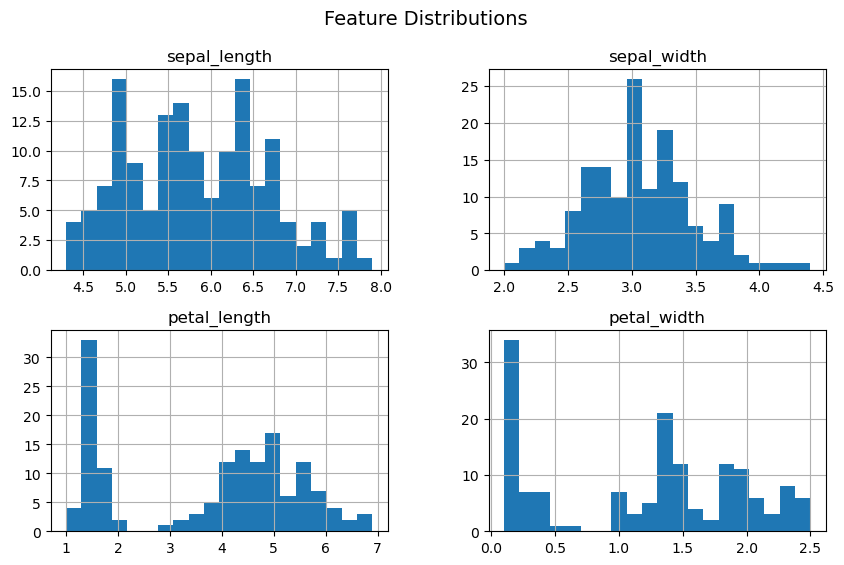

+----------+-----+
|   species|count|
+----------+-----+
| Virginica|   50|
|    Setosa|   50|
|Versicolor|   50|
+----------+-----+



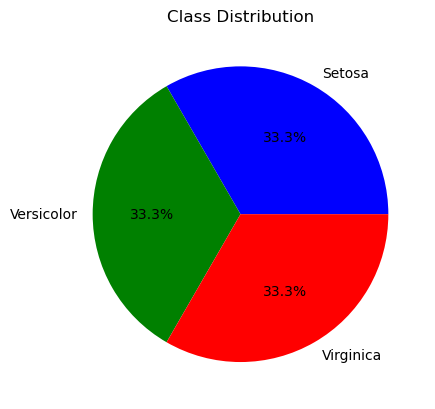

In [18]:
"""--------------------------------------------------------------------------
Perform Data Analytics
-------------------------------------------------------------------------"""

# Summary Statistics
iris_df.describe().show()

# Convert to Pandas for visualization
pandas_df = iris_df.toPandas()

# Plot histograms for each feature
pandas_df.hist(figsize=(10, 6), bins=20)
plt.suptitle("Feature Distributions", fontsize=14)
plt.show()

# Checking class distributions
iris_df.groupBy("species").count().show()

pandas_df["species"].value_counts().plot.pie(autopct="%1.1f%%", colors=["blue", "green", "red"])
plt.title("Class Distribution")
plt.ylabel("")
plt.show()

In [19]:
"""----------------------------------------------------------------------------
CREATING THE PIPELINE
----------------------------------------------------------------------------"""

# Convert categorical target column into numerical values
""" This part is necessary because ML models in 
    Spark require numerical labels.
"""
label_indexer = StringIndexer(inputCol="species", outputCol="label")

# Assemble feature columns into a single feature vector
feature_assembler = VectorAssembler(
    inputCols=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], 
    outputCol="features"
)

# Scale features
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures")

# Train-Test Split
train_df, test_df = iris_df.randomSplit([0.8, 0.2], seed=42)

# create evaluator
evaluator = MulticlassClassificationEvaluator(predictionCol="prediction", \
                        labelCol="label",metricName="accuracy")

In [20]:
def make_predictions_using_pipeline(model):
    # Build the pipeline
    pipeline = Pipeline(stages=[label_indexer, feature_assembler, scaler, model])

    # Train the model
    model = pipeline.fit(train_df)

    # Make predictions
    predictions = model.transform(test_df)

    predictions.select("prediction","species","label", "features").show(10)

    #Evaluate accuracy
    accuracy = evaluator.evaluate(predictions)    

    #Draw a confusion matrix
    predictions.groupBy("label","prediction").count().show()

    return accuracy    

In [21]:
# Decision Tree Model
from pyspark.ml.classification import DecisionTreeClassifier

dt = DecisionTreeClassifier(featuresCol="scaledFeatures", labelCol="label")

accuracy  = make_predictions_using_pipeline(dt)

# Print results
print(f"Decision Tree Accuracy: {accuracy:.4f}")

+----------+----------+-----+-----------------+
|prediction|   species|label|         features|
+----------+----------+-----+-----------------+
|       2.0|    Setosa|  2.0|[4.4,3.0,1.3,0.2]|
|       2.0|    Setosa|  2.0|[4.6,3.2,1.4,0.2]|
|       2.0|    Setosa|  2.0|[4.6,3.6,1.0,0.2]|
|       2.0|    Setosa|  2.0|[4.8,3.1,1.6,0.2]|
|       2.0|    Setosa|  2.0|[4.9,3.1,1.5,0.1]|
|       0.0|Versicolor|  0.0|[5.0,2.3,3.3,1.0]|
|       2.0|    Setosa|  2.0|[5.0,3.5,1.3,0.3]|
|       2.0|    Setosa|  2.0|[5.1,3.5,1.4,0.2]|
|       2.0|    Setosa|  2.0|[5.3,3.7,1.5,0.2]|
|       0.0|Versicolor|  0.0|[5.4,3.0,4.5,1.5]|
+----------+----------+-----+-----------------+
only showing top 10 rows

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  1.0|       1.0|    7|
|  2.0|       2.0|   11|
|  0.0|       0.0|    6|
+-----+----------+-----+

Decision Tree Accuracy: 1.0000


In [22]:
# Random Forest Classifier
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(featuresCol="scaledFeatures", labelCol="label", numTrees=20)

accuracy  = make_predictions_using_pipeline(rf)

# Print results
print(f"Random Forest Accuracy: {accuracy:.4f}")

+----------+----------+-----+-----------------+
|prediction|   species|label|         features|
+----------+----------+-----+-----------------+
|       2.0|    Setosa|  2.0|[4.4,3.0,1.3,0.2]|
|       2.0|    Setosa|  2.0|[4.6,3.2,1.4,0.2]|
|       2.0|    Setosa|  2.0|[4.6,3.6,1.0,0.2]|
|       2.0|    Setosa|  2.0|[4.8,3.1,1.6,0.2]|
|       2.0|    Setosa|  2.0|[4.9,3.1,1.5,0.1]|
|       0.0|Versicolor|  0.0|[5.0,2.3,3.3,1.0]|
|       2.0|    Setosa|  2.0|[5.0,3.5,1.3,0.3]|
|       2.0|    Setosa|  2.0|[5.1,3.5,1.4,0.2]|
|       2.0|    Setosa|  2.0|[5.3,3.7,1.5,0.2]|
|       0.0|Versicolor|  0.0|[5.4,3.0,4.5,1.5]|
+----------+----------+-----+-----------------+
only showing top 10 rows

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  1.0|       1.0|    7|
|  2.0|       2.0|   11|
|  0.0|       0.0|    6|
+-----+----------+-----+

Random Forest Accuracy: 1.0000


In [23]:
from pyspark.ml.classification import GBTClassifier, OneVsRest

# Define the base Gradient Boosted Tree Classifier (binary)
gbt = GBTClassifier(featuresCol="scaledFeatures", labelCol="label")

# Convert binary classifier into multi-class using OneVsRest
ovr = OneVsRest(classifier=gbt,featuresCol="scaledFeatures", labelCol="label")

accuracy = make_predictions_using_pipeline(ovr)

# Print results
print(f"Gradient Boosted Accuracy: {accuracy:.4f}")


+----------+----------+-----+-----------------+
|prediction|   species|label|         features|
+----------+----------+-----+-----------------+
|       2.0|    Setosa|  2.0|[4.4,3.0,1.3,0.2]|
|       2.0|    Setosa|  2.0|[4.6,3.2,1.4,0.2]|
|       2.0|    Setosa|  2.0|[4.6,3.6,1.0,0.2]|
|       2.0|    Setosa|  2.0|[4.8,3.1,1.6,0.2]|
|       2.0|    Setosa|  2.0|[4.9,3.1,1.5,0.1]|
|       0.0|Versicolor|  0.0|[5.0,2.3,3.3,1.0]|
|       2.0|    Setosa|  2.0|[5.0,3.5,1.3,0.3]|
|       2.0|    Setosa|  2.0|[5.1,3.5,1.4,0.2]|
|       2.0|    Setosa|  2.0|[5.3,3.7,1.5,0.2]|
|       0.0|Versicolor|  0.0|[5.4,3.0,4.5,1.5]|
+----------+----------+-----+-----------------+
only showing top 10 rows

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  1.0|       1.0|    7|
|  0.0|       1.0|    1|
|  2.0|       2.0|   11|
|  0.0|       0.0|    5|
+-----+----------+-----+

Gradient Boosted Accuracy: 0.9583
